In [30]:
#libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight

In [6]:
file_path = "/Users/rishithasp/Documents/SEM2/DeepLearning/Crime_Incidents_20250202.csv"
df = pd.read_csv(file_path)

df.drop(columns=["Case Number", "Incident ID", "updated_at", "Census Tract", "Census Block Group", "2010 Census Block Group"], inplace=True)

#Data pre processing
df.replace(["UNKNOWN", ""], np.nan, inplace=True)

numericCols = df.select_dtypes(include=[np.number]).columns.tolist()
categoricalCols = df.select_dtypes(include=['object']).columns.tolist()

num_imputer = SimpleImputer(strategy='mean')
df[numericCols] = num_imputer.fit_transform(df[numericCols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categoricalCols] = cat_imputer.fit_transform(df[categoricalCols])


#cleaning the mismatched string format
def cleanCategoricalData(df, categoricalCols):
    for col in categoricalCols:
        df[col] = df[col].astype(str)  # verify all are strings
        df[col] = df[col].str.strip()  # Remove spaces
        df[col] = df[col].str.lower()
        df[col] = df[col].replace(["n/a", "na", "not available", "-"], np.nan)  # Standardization of the missing values

    return df
df = cleanCategoricalData(df, categoricalCols)
print(df.head())

# Handling outliers
def handleOutliersOpt(df, numericCols, categoricalCols, method="remove"):
    Q1 = df[numericCols].quantile(0.25)
    Q3 = df[numericCols].quantile(0.75)
    IQR = Q3 - Q1
    lowerBound = Q1 - 1.5 * IQR
    upperBound = Q3 + 1.5 * IQR

    if method == "remove":
        mask = ((df[numericCols] >= lowerBound) & (df[numericCols] <= upperBound)).all(axis=1)
        df = df[mask]
    elif method == "impute":
        medians = df[numericCols].median()
        for col in numericCols:
            df[col] = df[col].mask((df[col] < lowerBound[col]) | (df[col] > upperBound[col]), medians[col])
    return df

df = handleOutliersOpt(df, numericCols, categoricalCols, method="impute")
print(df.head())
print(df.columns)

        Incident Datetime Incident Type Primary  \
0  06/14/2016 01:20:00 am               assault   
1  12/13/2016 05:00:00 am         larceny/theft   
2  07/19/2020 03:09:00 am               assault   
3  11/17/2014 08:08:00 am         larceny/theft   
4  04/20/2015 10:22:00 am         larceny/theft   

                                Incident Description Parent Incident Type  \
0                                            assault              assault   
1                                      larceny/theft                theft   
2  buffalo police are investigating this report o...              assault   
3                                      larceny/theft                theft   
4                                      larceny/theft                theft   

   Hour of Day Day of Week                      Address     City State  \
0          1.0     tuesday  e amherst st & e amherst st  buffalo    ny   
1          5.0     tuesday      1000 block e lovejoy st  buffalo    ny   
2       

<ipython-input-10-5e87743e921b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crimeCounts.index, y=crimeCounts.values, palette="coolwarm")


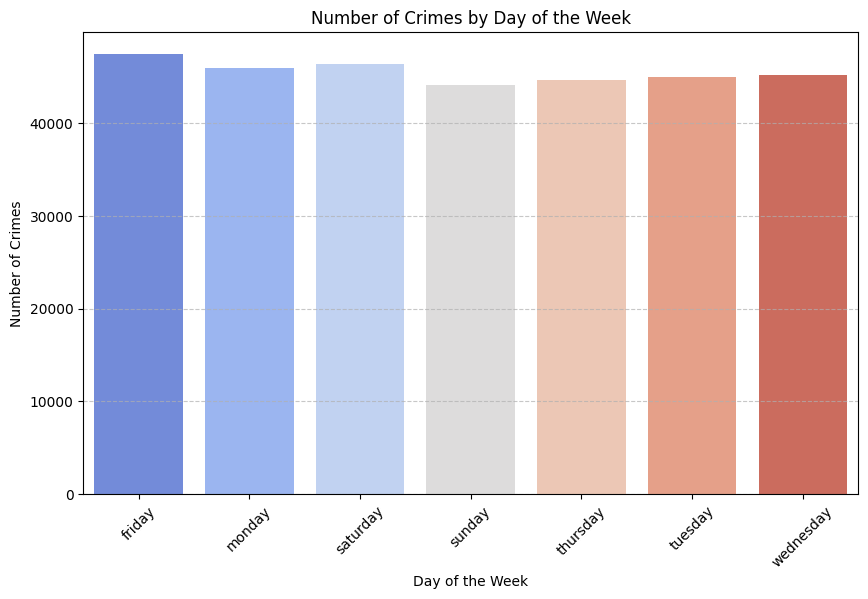

In [ ]:
#visualization 1:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crimeCounts = df["Day of Week"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=crimeCounts.index, y=crimeCounts.values, palette="coolwarm")

plt.xlabel("Day of the Week")
plt.ylabel("Number of Crimes")
plt.title("Number of Crimes by Day of the Week")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

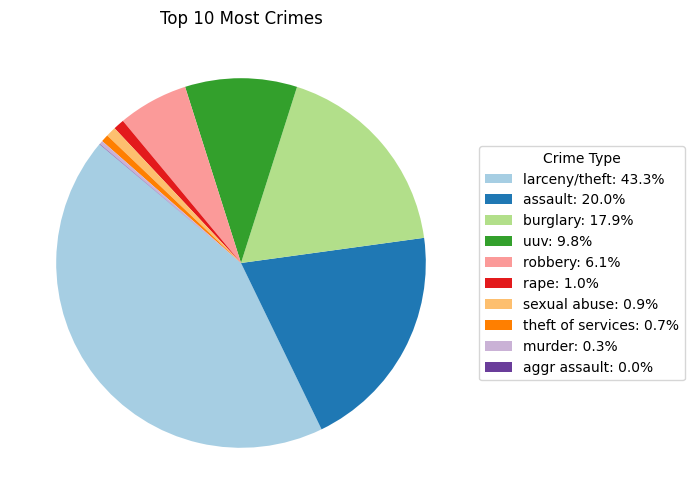

In [ ]:
#visualization 2
import matplotlib.pyplot as plt


crimeCounts = df['Incident Type Primary'].value_counts().nlargest(10)
crime_percentages = (crimeCounts / crimeCounts.sum()) * 100  # Calculating the  percentage
colors = plt.cm.Paired(range(len(crimeCounts)))

plt.figure(figsize=(10, 6))
wedges, _ = plt.pie(
    crimeCounts, labels=None, colors=colors, startangle=140
)
legend_labels = [f"{crime}: {perc:.1f}%" for crime, perc in zip(crimeCounts.index, crime_percentages)]
plt.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0.5), title="Crime Type", frameon=True)

plt.title("Top 10 Most Crimes")
plt.show()


<ipython-input-15-e685937c980d>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crimeByDistrict, y='Police District', x='Crime Count', palette='viridis')


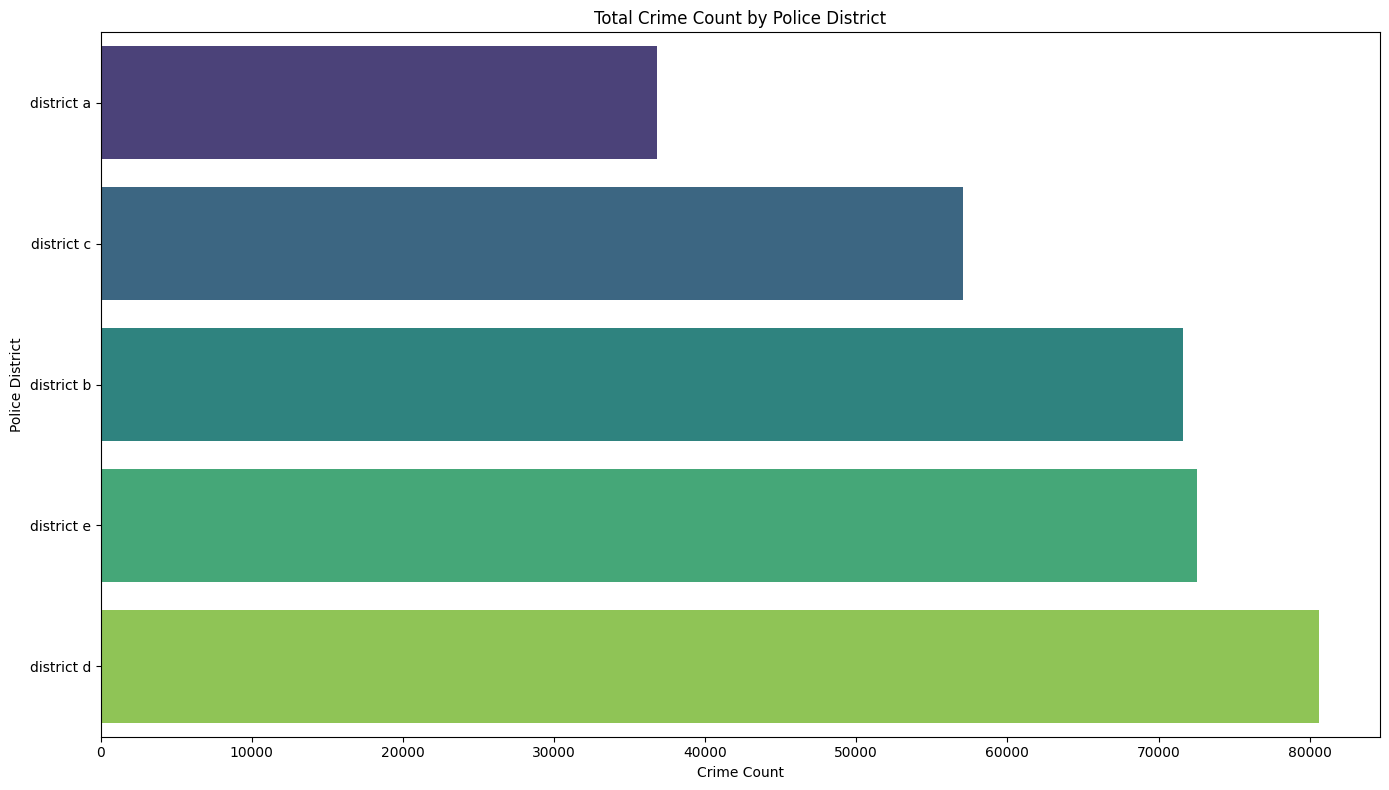

In [ ]:
#visualization 3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Police District
crimeByDistrict = df.groupby('Police District').size().reset_index(name='Crime Count')

crimeByDistrict = crimeByDistrict.sort_values('Crime Count', ascending=True)

plt.figure(figsize=(14, 8))
sns.barplot(data=crimeByDistrict, y='Police District', x='Crime Count', palette='viridis')

plt.xlabel("Crime Count")
plt.ylabel("Police District")
plt.title("Total Crime Count by Police District")

plt.tight_layout()
plt.show()

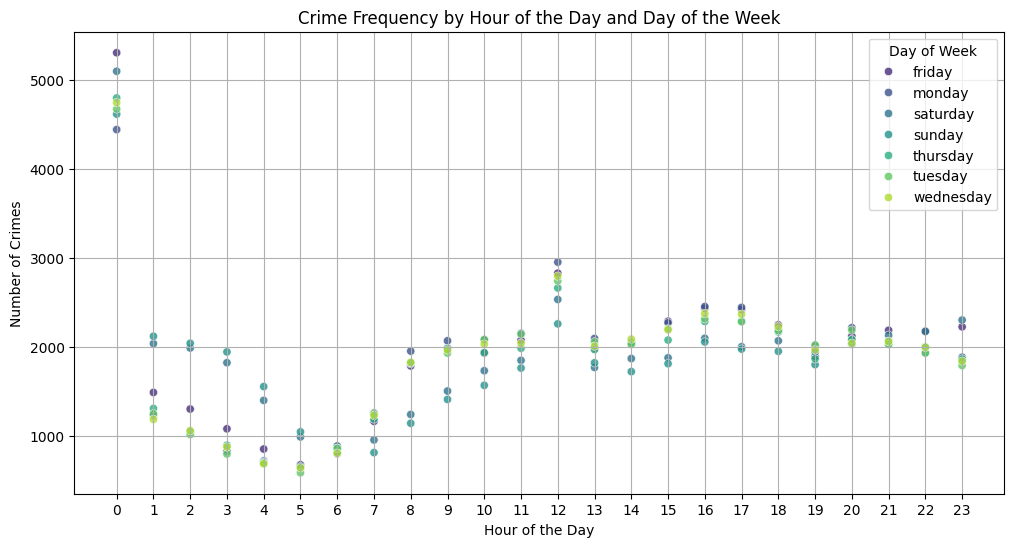

In [ ]:
#visualization 4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crimeCounts = df.groupby(['Hour of Day', 'Day of Week']).size().reset_index(name='Crime Count')

plt.figure(figsize=(12, 6))
sns.scatterplot(data=crimeCounts, x='Hour of Day', y='Crime Count', hue='Day of Week', palette='viridis', alpha=0.8)

plt.xlabel("Hour of the Day")
plt.ylabel("Number of Crimes")
plt.title("Crime Frequency by Hour of the Day and Day of the Week")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(title="Day of Week")

plt.show()

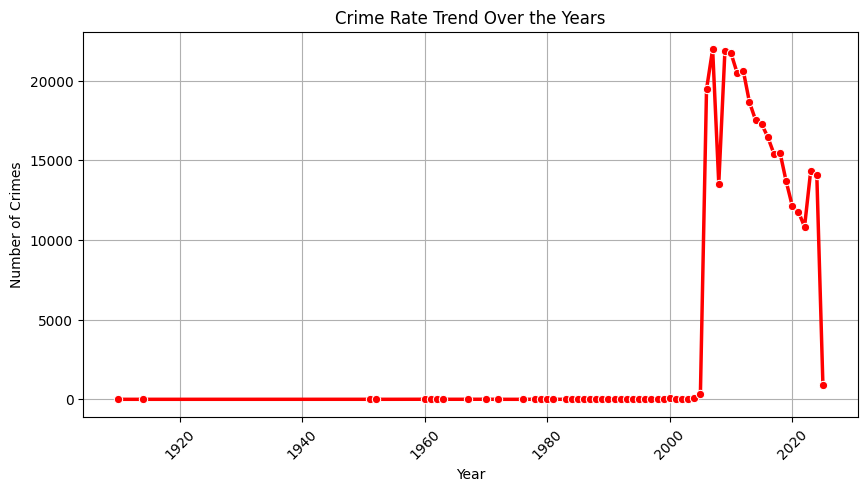

In [ ]:
#visualization 5
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#dateTime conversion
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'], format="%m/%d/%Y %I:%M:%S %p", errors='coerce')
df = df.dropna(subset=['Incident Datetime'])
df['Year'] = df['Incident Datetime'].dt.year

crimeTrend = df.groupby('Year').size().reset_index(name='Crime Count')

# Set plot style
plt.figure(figsize=(10, 5))
sns.lineplot(data=crimeTrend, x='Year', y='Crime Count', marker='o', linewidth=2.5, color='red')

# Labels and title
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.title("Crime Rate Trend Over the Years")
plt.xticks(rotation=45)
plt.grid(True)

# Show plot
plt.show()

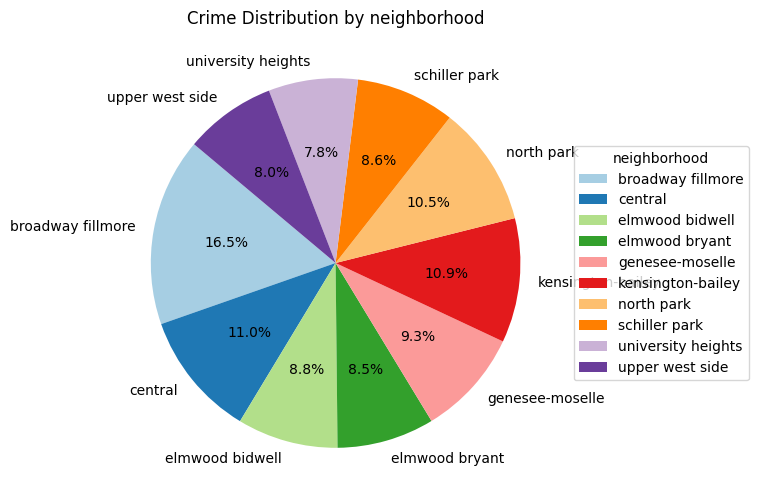

In [ ]:
#visualization 6
import pandas as pd
import matplotlib.pyplot as plt

crimeCountNeighbor = df.groupby(['neighborhood', 'Incident Type Primary']).size().reset_index(name='Crime Count')

topNeighborhoods = crimeCountNeighbor.groupby('neighborhood').sum().nlargest(10, 'Crime Count').index

neighData = crimeCountNeighbor[crimeCountNeighbor['neighborhood'].isin(topNeighborhoods)]

plt.figure(figsize=(10, 6))
crimeData = neighData.groupby('neighborhood')['Crime Count'].sum()

plt.pie(crimeData, labels=crimeData.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title("Crime Distribution by neighborhood")
plt.legend(crimeData.index, title="neighborhood", loc="center left", bbox_to_anchor=(1, 0.5))

plt.show()

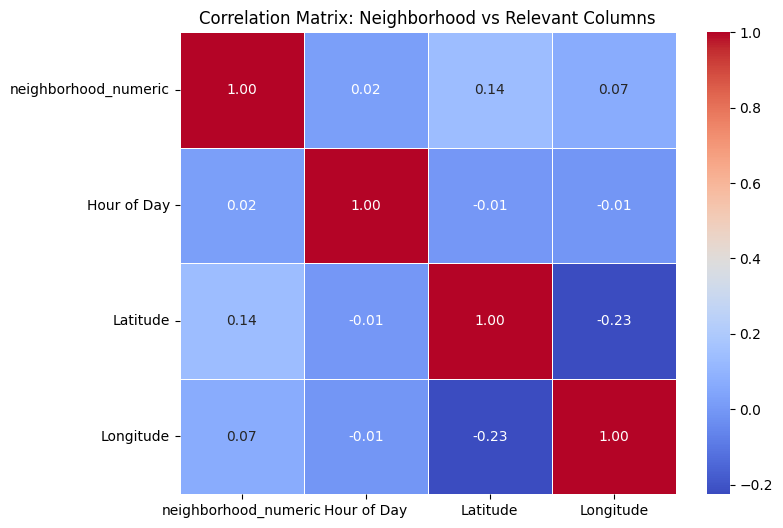

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['neighborhood_numeric'] = df['neighborhood'].astype('category').cat.codes
numeriCols = ['neighborhood_numeric', 'Hour of Day', 'Latitude', 'Longitude']
numDFrame = df[numeriCols]

#Compute the correlation matrix
corrMatrix = numDFrame.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Neighborhood vs Relevant Columns")
plt.show()

Logistic Regression: Validation Accuracy: 0.92, Test Accuracy: 0.92
Decision Tree: Validation Accuracy: 0.91, Test Accuracy: 0.91
Random Forest: Validation Accuracy: 0.88, Test Accuracy: 0.88


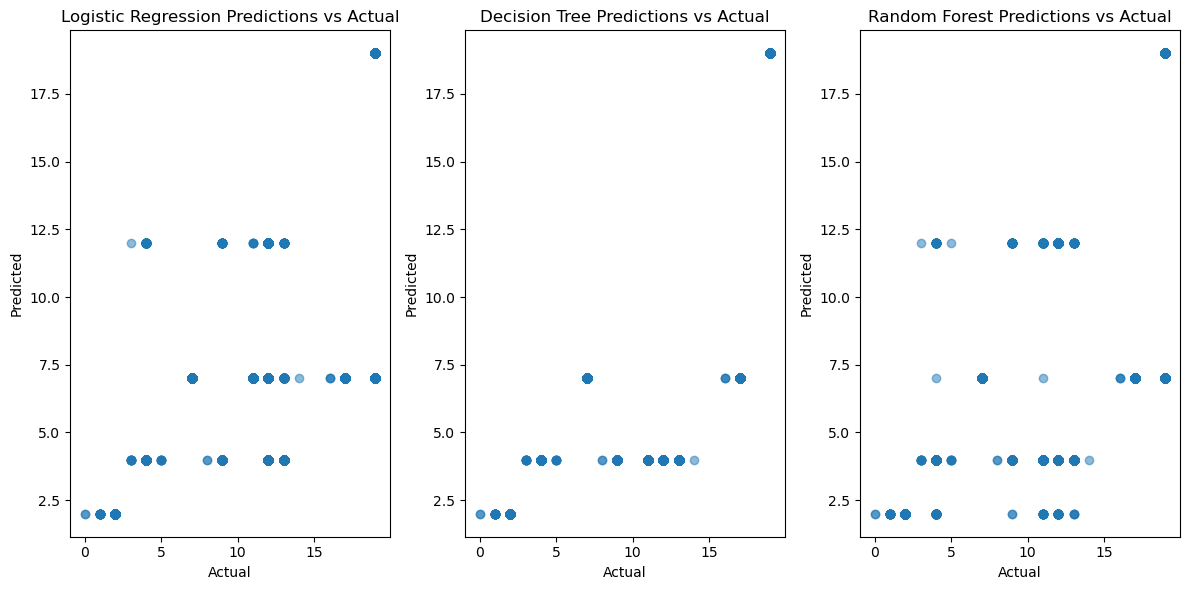

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df.dropna(subset=['Incident Type Primary'], inplace=True)
lblEncode = LabelEncoder()
df['Incident Type Primary'] = lblEncode.fit_transform(df['Incident Type Primary'])

X = df.drop(columns=['Incident Type Primary'])
y = df['Incident Type Primary']

numericCols = X.select_dtypes(include=['number']).columns
categoricalCols = X.select_dtypes(include=['object']).columns

datetimeCols = X.select_dtypes(include=['datetime64']).columns
X = X.drop(columns=datetimeCols, errors='ignore')

numImputer = SimpleImputer(strategy='mean')
catImputer = SimpleImputer(strategy='most_frequent')

X[numericCols] = numImputer.fit_transform(X[numericCols])
X[categoricalCols] = catImputer.fit_transform(X[categoricalCols])
for col in categoricalCols:
    X[col] = LabelEncoder().fit_transform(X[col])

X = X.drop(columns=['Latitude', 'Longitude'], errors='ignore')
X = X.drop(columns=['DateTimeColumnName'], errors='ignore')

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
dataMinMaxScalar = MinMaxScaler()
XTrainScaled = dataMinMaxScalar.fit_transform(X_train)
XValidationScaled = dataMinMaxScalar.transform(X_validation)
xTestScaled = dataMinMaxScalar.transform(X_test)

logisticRegressionModel = LogisticRegression(max_iter=500, random_state=42, C=0.01, penalty='l1', solver='liblinear')
decisionTreeModel = DecisionTreeClassifier(random_state=42, max_depth=2, min_samples_split=25)
randomForestModel = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=5, random_state=42)

models = {
    "Logistic Regression": logisticRegressionModel,
    "Decision Tree": decisionTreeModel,
    "Random Forest": randomForestModel
}

accuracyResults = {}
for name, model in models.items():
    model.fit(XTrainScaled, y_train)
    yValPred = model.predict(XValidationScaled)
    yTestPred = model.predict(xTestScaled)
    valAccuracy = accuracy_score(y_validation, yValPred)
    testAccuracy = accuracy_score(y_test, yTestPred)
    accuracyResults[name] = {
        'Validation Accuracy': valAccuracy,
        'Test Accuracy': testAccuracy
    }

    print(f"{name}: Validation Accuracy: {valAccuracy:.2f}, Test Accuracy: {testAccuracy:.2f}")

plt.figure(figsize=(12, 6))
for i, (name, model) in enumerate(models.items(), 1):
    yTestPred = model.predict(xTestScaled)
    plt.subplot(1, 3, i)
    plt.scatter(y_test, yTestPred, alpha=0.5)
    plt.title(f"{name} Predictions vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

Epoch 1/30: Train Acc: 0.70, Val Acc: 0.78
Epoch 2/30: Train Acc: 0.75, Val Acc: 0.79
Epoch 3/30: Train Acc: 0.75, Val Acc: 0.78
Epoch 4/30: Train Acc: 0.75, Val Acc: 0.79
Epoch 5/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 6/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 7/30: Train Acc: 0.76, Val Acc: 0.80
Epoch 8/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 9/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 10/30: Train Acc: 0.76, Val Acc: 0.80
Epoch 11/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 12/30: Train Acc: 0.76, Val Acc: 0.80
Epoch 13/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 14/30: Train Acc: 0.76, Val Acc: 0.80
Epoch 15/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 16/30: Train Acc: 0.76, Val Acc: 0.80
Epoch 17/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 18/30: Train Acc: 0.76, Val Acc: 0.80
Epoch 19/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 20/30: Train Acc: 0.76, Val Acc: 0.78
Epoch 21/30: Train Acc: 0.76, Val Acc: 0.79
Epoch 22/30: Train Acc: 0.76, Val Acc: 0.78
Epoch 23/30: Train Acc: 0.76, Val Acc: 0.

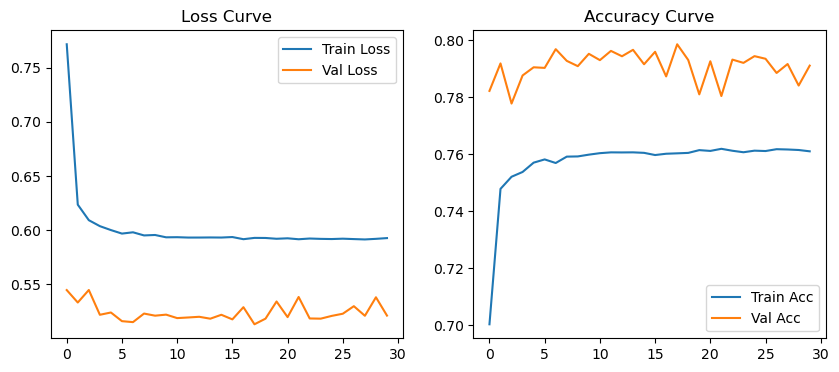

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

X = np.array(X)
y = np.array(y)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


lblEncode = LabelEncoder()
lblEncode.fit(np.concatenate([y_train, y_validation, y_test]))
y_train = lblEncode.transform(y_train)
y_validation = lblEncode.transform(y_validation)
y_test = lblEncode.transform(y_test)

stdScalerFeat = StandardScaler()
X_train = stdScalerFeat.fit_transform(X_train)
X_validation = stdScalerFeat.transform(X_validation)
X_test = stdScalerFeat.transform(X_test)

X_train += np.random.normal(0, 0.2, X_train.shape)
X_validation += np.random.normal(0, 0.2, X_validation.shape)
X_test += np.random.normal(0, 0.2, X_test.shape)

trainingLoader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
valueLoadere = DataLoader(TensorDataset(torch.tensor(X_validation, dtype=torch.float32), torch.tensor(y_validation, dtype=torch.long)), batch_size=32, shuffle=False)
testingLOader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)), batch_size=32, shuffle=False)

class tinyModelNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

model = tinyModelNN(X_train.shape[1], len(lblEncode.classes_))
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # Added weight decay
criterion = nn.CrossEntropyLoss()


epochs = 30
trainHist, valHist = [], []

for epoch in range(epochs):
    model.train()
    correct, total, lossSumm = 0, 0, 0
    for X_batch, y_batch in trainingLoader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        lossSumm += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    trainHist.append((lossSumm / len(trainingLoader), correct / total))

    # Validation
    model.eval()
    with torch.no_grad():
        correct, total, lossSumm = 0, 0, 0
        for X_val, y_val in valueLoadere:
            outputs = model(X_val)
            lossSumm += criterion(outputs, y_val).item()
            correct += (outputs.argmax(1) == y_val).sum().item()
            total += y_val.size(0)
        valHist.append((lossSumm / len(valueLoadere), correct / total))

    print(f"Epoch {epoch+1}/{epochs}: Train Acc: {trainHist[-1][1]:.2f}, Val Acc: {valHist[-1][1]:.2f}")

torch.save(model.state_dict(), "a0_part_2_rsaravan.pt")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in testingLOader:
        correct += (model(X_batch).argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
testAccuracyyy = correct / total

print(f"Neural Network - Final Validation Accuracy: {valHist[-1][1]:.2f}")
print(f"Neural Network - Test Accuracy: {correct / total:.2f}")
print(f"Neural Network - Final Validation Loss: {valHist[-1][0]:.4f}")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot([x[0] for x in trainHist], label="Train Loss")
plt.plot([x[0] for x in valHist], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1, 2, 2)
plt.plot([x[1] for x in trainHist], label="Train Acc")
plt.plot([x[1] for x in valHist], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


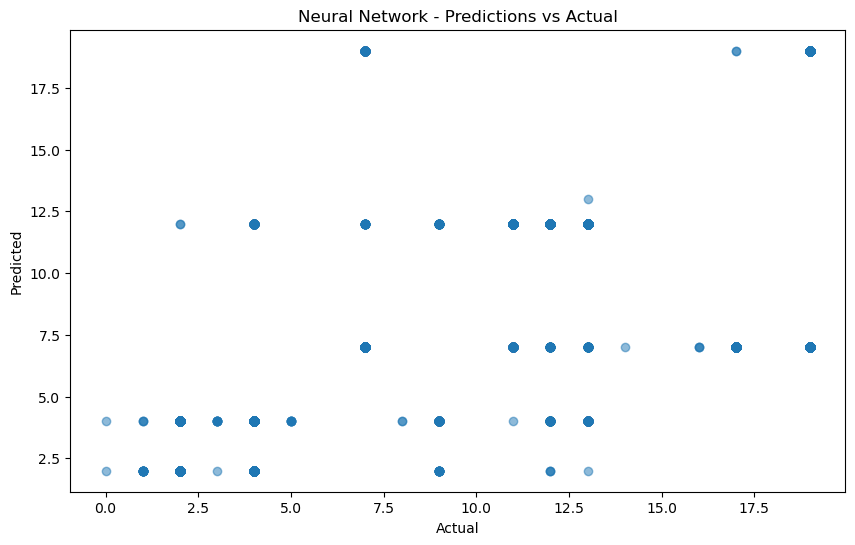

In [12]:

import time
model.eval()
start_time = time.time() 
with torch.no_grad():
    all_preds = []
    all_true = []
    for X_batch, y_batch in testingLOader:
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        all_preds.extend(preds.numpy())
        all_true.extend(y_batch.numpy())
end_time = time.time()
nnInferenceTime = end_time - start_time
plt.figure(figsize=(10, 6))
plt.scatter(all_true, all_preds, alpha=0.5)
plt.title("Neural Network - Predictions vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


In [16]:
import time

mlInferTimes = {} 

for name, model in models.items():
    start_time = time.time()
    yTestPred = model.predict(xTestScaled)
    end_time = time.time()

    inference_time = end_time - start_time  
    mlInferTimes[name] = inference_time  
    accuracyResults[name]['Inference Time (s)'] = inference_time

    print(f"{name}: Inference Time: {inference_time:.4f} sec")

Logistic Regression: Inference Time: 0.0214 sec
Decision Tree: Inference Time: 0.0053 sec
Random Forest: Inference Time: 0.1513 sec


                 Model  Test Accuracy  Inference Time
0       Neural Network       0.788941        0.195751
1  Logistic Regression       0.918593        0.021373
2        Decision Tree       0.909116        0.005264
3        Random Forest       0.882901        0.151264


NameError: name 'comparison_df' is not defined

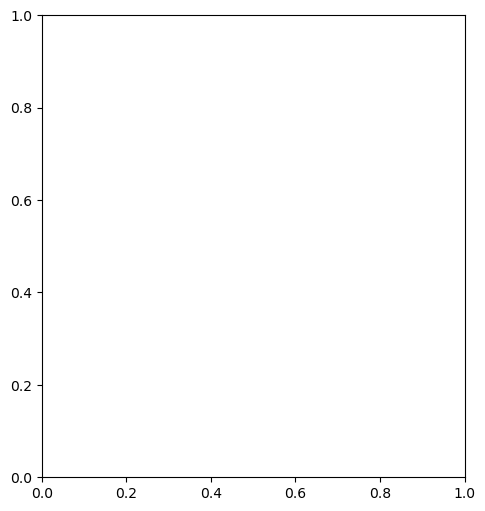

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparisonData = {
    'Model': ['Neural Network'] + list(accuracyResults.keys()),
    'Test Accuracy': [correct / total] + [accuracyResults[model]['Test Accuracy'] for model in accuracyResults],
    'Inference Time': [nnInferenceTime] + [mlInferTimes[model] for model in accuracyResults]
}

comparisonDf = pd.DataFrame(comparisonData)
print(comparisonDf)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(comparison_df['Model'], comparisonDf['Test Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(comparison_df['Model'], comparisonDf['Inference Time'])
plt.title('Model Inference Time Comparison')
plt.ylabel('Inference Time (seconds)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


accuracy_results = {
    "Logistic Regression": {'Validation Accuracy': accuracyResults["Logistic Regression"]['Validation Accuracy'],
                            'Test Accuracy': accuracyResults["Logistic Regression"]['Test Accuracy']},
    "Decision Tree": {'Validation Accuracy': accuracyResults["Decision Tree"]['Validation Accuracy'],
                      'Test Accuracy': accuracyResults["Decision Tree"]['Test Accuracy']},
    "Random Forest": {'Validation Accuracy': accuracyResults["Random Forest"]['Validation Accuracy'],
                      'Test Accuracy': accuracyResults["Random Forest"]['Test Accuracy']},
    "Neural Network": {'Validation Accuracy': trainHist[-1][0], 'Test Accuracy': correct / total} 
}

fig, ax = plt.subplots(figsize=(10, 6))
models = list(accuracy_results.keys())
ValAcc = [accuracy_results[model]['Validation Accuracy'] for model in models]
testAcc = [accuracy_results[model]['Test Accuracy'] for model in models]

bar_width = 0.35

index = np.arange(len(models))

bar1 = ax.bar(index, ValAcc, bar_width, label='Validation Accuracy', color='purple')
bar2 = ax.bar(index + bar_width, testAcc, bar_width, label='Test Accuracy', color='pink')

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Validation vs Test Accuracy')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()
